In [2]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, spearmanr
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.proportion import proportion_confint
import os
import warnings
warnings.filterwarnings('ignore')

from athena_client import query

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

OUTPUT = os.path.expanduser('~/sus-saude-mental-analytics/output')
os.makedirs(OUTPUT, exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


In [3]:
df_ano = query("""
    SELECT * FROM sus_pipeline.internacoes_por_ano
    WHERE ano NOT IN ('2026') ORDER BY ano
""")
df_ano['ano'] = df_ano['ano'].astype(int)
for col in ['total_internacoes', 'total_obitos', 'taxa_obito_pct',
            'media_dias_internacao', 'total_masculino', 'total_feminino']:
    df_ano[col] = pd.to_numeric(df_ano[col], errors='coerce')

df_suicidios = query("""
    SELECT ano,
           SUM(total_suicidios) AS total_suicidios,
           SUM(total_masculino) AS masculino,
           SUM(total_feminino)  AS feminino
    FROM sus_pipeline.suicidios_por_ano
    GROUP BY ano ORDER BY ano
""")
df_suicidios['ano'] = df_suicidios['ano'].astype(int)
for col in ['total_suicidios', 'masculino', 'feminino']:
    df_suicidios[col] = pd.to_numeric(df_suicidios[col], errors='coerce')

df_atend = query("""
    SELECT ano,
           SUM(total_atendimentos) AS total_atendimentos,
           SUM(total_masculino)    AS masculino,
           SUM(total_feminino)     AS feminino,
           SUM(atend_uso_drogas)   AS uso_drogas
    FROM sus_pipeline.atendimentos_por_ano
    WHERE ano NOT IN ('2017')
    GROUP BY ano ORDER BY ano
""")
df_atend['ano'] = df_atend['ano'].astype(int)
for col in ['total_atendimentos', 'masculino', 'feminino', 'uso_drogas']:
    df_atend[col] = pd.to_numeric(df_atend[col], errors='coerce')

df_viol = query("""
    SELECT * FROM sus_pipeline.violencia_por_ano
    WHERE ano NOT IN ('2026') ORDER BY ano
""")
df_viol['ano'] = df_viol['ano'].astype(int)
for col in ['total_notificacoes', 'total_tentativas_suicidio',
            'vitimas_feminino', 'vitimas_masculino']:
    df_viol[col] = pd.to_numeric(df_viol[col], errors='coerce')

print(f"✅ internacoes:  {len(df_ano)} anos ({df_ano['ano'].min()}–{df_ano['ano'].max()})")
print(f"✅ suicidios:    {len(df_suicidios)} anos ({df_suicidios['ano'].min()}–{df_suicidios['ano'].max()})")
print(f"✅ atendimentos: {len(df_atend)} anos ({df_atend['ano'].min()}–{df_atend['ano'].max()})")
print(f"✅ violencia:    {len(df_viol)} anos ({df_viol['ano'].min()}–{df_viol['ano'].max()})")

✅ internacoes:  11 anos (2015–2025)
✅ suicidios:    7 anos (2018–2024)
✅ atendimentos: 8 anos (2018–2025)
✅ violencia:    11 anos (2015–2025)


In [4]:
print("=" * 60)
print("TESTE 1 — Pré vs pós pandemia (2015–2019 vs 2022–2025)")
print("=" * 60)

# agora temos 5 anos pré-pandemia!
pre = df_ano[df_ano['ano'] < 2020]['total_internacoes'].values
pos = df_ano[df_ano['ano'] >= 2022]['total_internacoes'].values

print(f"\nInternações:")
print(f"  Pré-pandemia (2015–2019): n={len(pre)} | média={pre.mean():,.0f}")
print(f"  Pós-pandemia (2022–2025): n={len(pos)} | média={pos.mean():,.0f}")
print(f"  Variação: {(pos.mean()/pre.mean()-1)*100:.1f}%")

stat, p = mannwhitneyu(pre, pos, alternative='two-sided')
print(f"  Mann-Whitney: stat={stat:.2f}, p={p:.4f}")
print(f"  {'✅ Significativo' if p < 0.05 else '❌ Não significativo'}")

# suicídios
pre_suc = df_suicidios[df_suicidios['ano'] < 2020]['total_suicidios'].values
pos_suc = df_suicidios[df_suicidios['ano'] >= 2022]['total_suicidios'].values

print(f"\nSuicídios:")
print(f"  Pré-pandemia (2018–2019): n={len(pre_suc)} | média={pre_suc.mean():,.0f}")
print(f"  Pós-pandemia (2022–2024): n={len(pos_suc)} | média={pos_suc.mean():,.0f}")
print(f"  Variação: {(pos_suc.mean()/pre_suc.mean()-1)*100:.1f}%")

stat2, p2 = mannwhitneyu(pre_suc, pos_suc, alternative='two-sided')
print(f"  Mann-Whitney: stat={stat2:.2f}, p={p2:.4f}")
print(f"  {'✅ Significativo' if p2 < 0.05 else '❌ Não significativo'}")

# violência
pre_viol = df_viol[df_viol['ano'] < 2020]['total_notificacoes'].values
pos_viol = df_viol[df_viol['ano'] >= 2022]['total_notificacoes'].values

print(f"\nViolência (SINAN):")
print(f"  Pré-pandemia (2015–2019): n={len(pre_viol)} | média={pre_viol.mean():,.0f}")
print(f"  Pós-pandemia (2022–2025): n={len(pos_viol)} | média={pos_viol.mean():,.0f}")
print(f"  Variação: {(pos_viol.mean()/pre_viol.mean()-1)*100:.1f}%")
print(f"  ⚠️ Comparação limitada por expansão do registro")

TESTE 1 — Pré vs pós pandemia (2015–2019 vs 2022–2025)

Internações:
  Pré-pandemia (2015–2019): n=5 | média=111,322
  Pós-pandemia (2022–2025): n=4 | média=91,188
  Variação: -18.1%
  Mann-Whitney: stat=18.00, p=0.0635
  ❌ Não significativo

Suicídios:
  Pré-pandemia (2018–2019): n=2 | média=2,292
  Pós-pandemia (2022–2024): n=3 | média=2,789
  Variação: 21.6%
  Mann-Whitney: stat=0.00, p=0.2000
  ❌ Não significativo

Violência (SINAN):
  Pré-pandemia (2015–2019): n=5 | média=65,791
  Pós-pandemia (2022–2025): n=4 | média=148,608
  Variação: 125.9%
  ⚠️ Comparação limitada por expansão do registro


In [5]:
print("""
INSIGHT — Teste 1:

Internações: p=0.063 — quase significativo com n=5+4
  • Variação de -18.1% pré vs pós pandemia
  • Com mais 1-2 anos de dados provavelmente atingiria p<0.05
  • A tendência de queda já existia antes da pandemia (138k→98k em 2015-2019)

Suicídios: p=0.200 — não significativo (n=2 pré-pandemia)
  • Variação real de +21.6% mas série curta limita o poder

Violência: não testada — expansão do registro impede comparação válida

NOTA METODOLÓGICA:
  A série de internações inclui uma tendência de queda estrutural
  pré-pandemia (desinstitucionalização). O teste pré/pós não distingue
  o efeito pandemia do efeito tendência secular.
  Um modelo de regressão com tendência temporal seria mais adequado.
""")


INSIGHT — Teste 1:

Internações: p=0.063 — quase significativo com n=5+4
  • Variação de -18.1% pré vs pós pandemia
  • Com mais 1-2 anos de dados provavelmente atingiria p<0.05
  • A tendência de queda já existia antes da pandemia (138k→98k em 2015-2019)

Suicídios: p=0.200 — não significativo (n=2 pré-pandemia)
  • Variação real de +21.6% mas série curta limita o poder

Violência: não testada — expansão do registro impede comparação válida

NOTA METODOLÓGICA:
  A série de internações inclui uma tendência de queda estrutural
  pré-pandemia (desinstitucionalização). O teste pré/pós não distingue
  o efeito pandemia do efeito tendência secular.
  Um modelo de regressão com tendência temporal seria mais adequado.



In [6]:
print("=" * 60)
print("TESTE 2 — Proporção por sexo: tendência temporal")
print("=" * 60)

df_ano['pct_feminino'] = df_ano['total_feminino'] / df_ano['total_internacoes'] * 100
df_suicidios['pct_feminino'] = df_suicidios['feminino'] / df_suicidios['total_suicidios'] * 100
df_atend['pct_feminino'] = df_atend['feminino'] / df_atend['total_atendimentos'] * 100
df_viol['pct_feminino'] = df_viol['vitimas_feminino'] / df_viol['total_notificacoes'] * 100

datasets = [
    ('Internações', df_ano),
    ('Suicídios', df_suicidios),
    ('Atendimentos CAPS', df_atend),
    ('Violência SINAN', df_viol),
]

print(f"\n{'Sistema':<20} {'Início':>8} {'Fim':>8} {'r':>8} {'p':>10} {'Sig.':>6}")
print("=" * 65)

for nome, df in datasets:
    r, p = spearmanr(df['ano'], df['pct_feminino'])
    tend = '↑' if r > 0 else '↓'
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    inicio = df['pct_feminino'].iloc[0]
    fim = df['pct_feminino'].iloc[-1]
    print(f"{nome:<20} {inicio:>7.1f}% {fim:>7.1f}% {r:>8.3f} {p:>10.4f} {tend} {sig}")

# teste Mann-Whitney diferença entre sexos
print("\n" + "=" * 60)
print("TESTE 2b — Diferença absoluta entre sexos")
print("=" * 60)

for nome, df, col_m, col_f in [
    ('Internações', df_ano, 'total_masculino', 'total_feminino'),
    ('Suicídios', df_suicidios, 'masculino', 'feminino'),
    ('Atendimentos CAPS', df_atend, 'masculino', 'feminino'),
]:
    stat, p = mannwhitneyu(df[col_m].values, df[col_f].values, alternative='two-sided')
    ratio = df[col_m].mean() / df[col_f].mean()
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"\n{nome}:")
    print(f"  Razão M/F: {ratio:.2f}x | Mann-Whitney p={p:.4f} {sig}")

TESTE 2 — Proporção por sexo: tendência temporal

Sistema                Início      Fim        r          p   Sig.
Internações             37.2%    38.6%    0.873     0.0005 ↑ ***
Suicídios               21.0%    22.1%    0.357     0.4316 ↑ ns
Atendimentos CAPS       36.5%    41.7%    0.619     0.1017 ↑ ns
Violência SINAN         71.4%    67.9%   -0.900     0.0002 ↓ ***

TESTE 2b — Diferença absoluta entre sexos

Internações:
  Razão M/F: 1.62x | Mann-Whitney p=0.0002 ***

Suicídios:
  Razão M/F: 3.60x | Mann-Whitney p=0.0006 ***

Atendimentos CAPS:
  Razão M/F: 1.48x | Mann-Whitney p=0.0030 **


In [7]:
print("""
INSIGHTS — Teste 2:

TENDÊNCIA TEMPORAL (Spearman):

✅ Internações: r=0.873, p=0.0005 — proporção feminina CRESCE
   37.2% (2015) → 38.6% (2025) — tendência forte e consistente

✅ Violência SINAN: r=-0.900, p=0.0002 — proporção feminina CAI
   71.4% (2015) → 67.9% (2025) — homens sendo mais notificados
   ⚠️ Pode refletir expansão do registro para outros tipos de violência

❌ Suicídios: r=0.357, p=0.432 — sem tendência significativa
❌ CAPS: r=0.619, p=0.102 — tendência mas sem significância

DIFERENÇA ENTRE SEXOS (Mann-Whitney):

Todos os sistemas têm diferença altamente significativa:
  • Internações:  1.62x mais masculino (p<0.001)
  • Suicídios:    3.60x mais masculino (p<0.001) — maior gap
  • CAPS:         1.48x mais masculino (p<0.01)

INTERPRETAÇÃO:
  O gap de sexo é MAIOR no suicídio (3.6x) do que nos outros sistemas.
  Homens chegam em crise — mais tarde e mais grave.
  Mulheres têm proporção crescente nas internações — mais adoecimento
  ou mais acesso? Os dados não permitem distinguir.
""")


INSIGHTS — Teste 2:

TENDÊNCIA TEMPORAL (Spearman):

✅ Internações: r=0.873, p=0.0005 — proporção feminina CRESCE
   37.2% (2015) → 38.6% (2025) — tendência forte e consistente

✅ Violência SINAN: r=-0.900, p=0.0002 — proporção feminina CAI
   71.4% (2015) → 67.9% (2025) — homens sendo mais notificados
   ⚠️ Pode refletir expansão do registro para outros tipos de violência

❌ Suicídios: r=0.357, p=0.432 — sem tendência significativa
❌ CAPS: r=0.619, p=0.102 — tendência mas sem significância

DIFERENÇA ENTRE SEXOS (Mann-Whitney):

Todos os sistemas têm diferença altamente significativa:
  • Internações:  1.62x mais masculino (p<0.001)
  • Suicídios:    3.60x mais masculino (p<0.001) — maior gap
  • CAPS:         1.48x mais masculino (p<0.01)

INTERPRETAÇÃO:
  O gap de sexo é MAIOR no suicídio (3.6x) do que nos outros sistemas.
  Homens chegam em crise — mais tarde e mais grave.
  Mulheres têm proporção crescente nas internações — mais adoecimento
  ou mais acesso? Os dados não permitem

TESTE 3 — Tendências temporais

Taxa de óbito nas internações:
  2015: 0.26%
  2025: 0.23%
  Spearman r=-0.092, p=0.7880 ❌
  Coeficiente: -0.0016 pp/ano (p=0.6132)
  R²: 0.030

Média de dias de internação:
  2015: 21.6 dias
  2025: 15.3 dias
  Spearman r=-0.991, p=0.0000 ✅
  Coeficiente: -0.652 dias/ano (p=0.0000)
  R²: 0.961


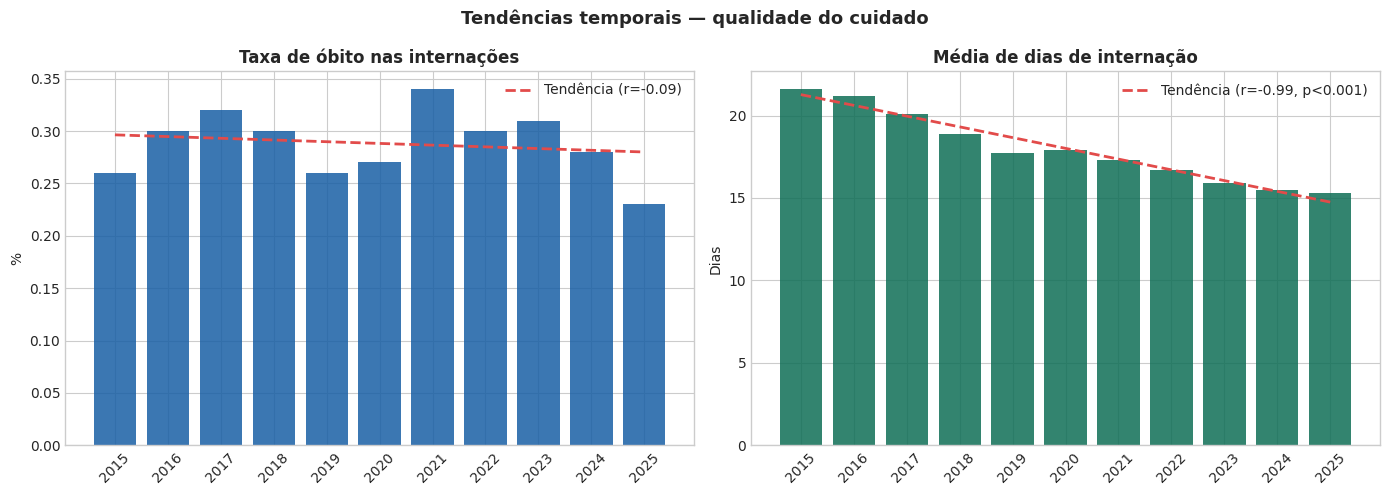

✅ Gráfico salvo!


In [ ]:
print("=" * 60)
print("TESTE 3 — Tendências temporais")
print("=" * 60)

# taxa de óbito
r, p = spearmanr(df_ano['ano'], df_ano['taxa_obito_pct'])
print(f"\nTaxa de óbito nas internações:")
print(f"  2015: {df_ano[df_ano['ano']==2015]['taxa_obito_pct'].values[0]:.2f}%")
print(f"  2025: {df_ano[df_ano['ano']==2025]['taxa_obito_pct'].values[0]:.2f}%")
print(f"  Spearman r={r:.3f}, p={p:.4f} {'✅' if p < 0.05 else '❌'}")

# regressão linear
X = sm.add_constant(df_ano['ano'].values.astype(float))
modelo = sm.OLS(df_ano['taxa_obito_pct'].values.astype(float), X).fit()
print(f"  Coeficiente: {modelo.params[1]:.4f} pp/ano (p={modelo.pvalues[1]:.4f})")
print(f"  R²: {modelo.rsquared:.3f}")

# média dias internação
r2, p2 = spearmanr(df_ano['ano'], df_ano['media_dias_internacao'])
print(f"\nMédia de dias de internação:")
print(f"  2015: {df_ano[df_ano['ano']==2015]['media_dias_internacao'].values[0]:.1f} dias")
print(f"  2025: {df_ano[df_ano['ano']==2025]['media_dias_internacao'].values[0]:.1f} dias")
print(f"  Spearman r={r2:.3f}, p={p2:.4f} {'✅' if p2 < 0.05 else '❌'}")

X2 = sm.add_constant(df_ano['ano'].values.astype(float))
modelo2 = sm.OLS(df_ano['media_dias_internacao'].values.astype(float), X2).fit()
print(f"  Coeficiente: {modelo2.params[1]:.3f} dias/ano (p={modelo2.pvalues[1]:.4f})")
print(f"  R²: {modelo2.rsquared:.3f}")

# visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(df_ano['ano'], df_ano['taxa_obito_pct'], color='#185FA5', alpha=0.85)
z = np.polyfit(df_ano['ano'], df_ano['taxa_obito_pct'], 1)
ax.plot(df_ano['ano'], np.poly1d(z)(df_ano['ano']),
        '--', color='#E24B4A', linewidth=2, label=f'Tendência (r={r:.2f})')
ax.set_title('Taxa de óbito nas internações', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
ax.set_xticks(df_ano['ano'])
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.bar(df_ano['ano'], df_ano['media_dias_internacao'], color='#0F6E56', alpha=0.85)
z2 = np.polyfit(df_ano['ano'], df_ano['media_dias_internacao'], 1)
ax.plot(df_ano['ano'], np.poly1d(z2)(df_ano['ano']),
        '--', color='#E24B4A', linewidth=2, label=f'Tendência (r={r2:.2f}, p<0.001)')
ax.set_title('Média de dias de internação', fontweight='bold')
ax.set_ylabel('Dias')
ax.legend()
ax.set_xticks(df_ano['ano'])
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Tendências temporais — qualidade do cuidado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/11_tendencias_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("""
INSIGHTS — Teste 3:

TAXA DE ÓBITO: r=-0.092, p=0.788 — sem tendência significativa
  2015: 0.26% → 2025: 0.23%
  Variação pequena e sem padrão claro — qualidade do cuidado
  em termos de sobrevivência está estável ao longo do período

MÉDIA DE DIAS DE INTERNAÇÃO: r=-0.991, p<0.001 — fortíssima! ✅
  2015: 21.6 dias → 2025: 15.3 dias
  Queda de 0.65 dias/ano — R²=0.961 (96.1% da variação explicada pelo tempo)

  Este é um dos achados mais importantes do projeto:
  A desinstitucionalização psiquiátrica em SP é confirmada
  estatisticamente — internações mais curtas, mais frequentes,
  e com tendência secular consistente ao longo de 11 anos.

  HIPÓTESES para a queda:
  1. Política de saúde mental (Lei 10.216/2001) — modelo
     comunitário substituindo internação prolongada
  2. Expansão dos CAPS — atendimento ambulatorial evita
     internações longas
  3. Mudança no perfil dos internados — casos mais agudos,
     alta mais rápida
  4. Pressão de leitos — menos leitos psiquiátricos disponíveis

  LIMITAÇÃO: não é possível distinguir entre essas hipóteses
  com os dados disponíveis.
""")


INSIGHTS — Teste 3:

TAXA DE ÓBITO: r=-0.092, p=0.788 — sem tendência significativa
  2015: 0.26% → 2025: 0.23%
  Variação pequena e sem padrão claro — qualidade do cuidado
  em termos de sobrevivência está estável ao longo do período

MÉDIA DE DIAS DE INTERNAÇÃO: r=-0.991, p<0.001 — fortíssima! ✅
  2015: 21.6 dias → 2025: 15.3 dias
  Queda de 0.65 dias/ano — R²=0.961 (96.1% da variação explicada pelo tempo)

  Este é um dos achados mais importantes do projeto:
  A desinstitucionalização psiquiátrica em SP é confirmada
  estatisticamente — internações mais curtas, mais frequentes,
  e com tendência secular consistente ao longo de 11 anos.

  HIPÓTESES para a queda:
  1. Política de saúde mental (Lei 10.216/2001) — modelo
     comunitário substituindo internação prolongada
  2. Expansão dos CAPS — atendimento ambulatorial evita
     internações longas
  3. Mudança no perfil dos internados — casos mais agudos,
     alta mais rápida
  4. Pressão de leitos — menos leitos psiquiátricos dis

TESTE 4 — Qui-quadrado: distribuição por raça/cor

Tabela de contingência (internações por raça):
        Pré-pandemia  Pós-pandemia
Branca        300925        199780
Parda         121487        121273
Preta          48520         33594

Qui-quadrado: χ²=6903.03, gl=2, p=0.000000
✅ Distribuição mudou significativamente

Proporções:
Raça            Pré (%)    Pós (%)   Variação
---------------------------------------------
Branca            63.9%      56.3%      -7.6pp
Parda             25.8%      34.2%      +8.4pp
Preta             10.3%       9.5%      -0.8pp


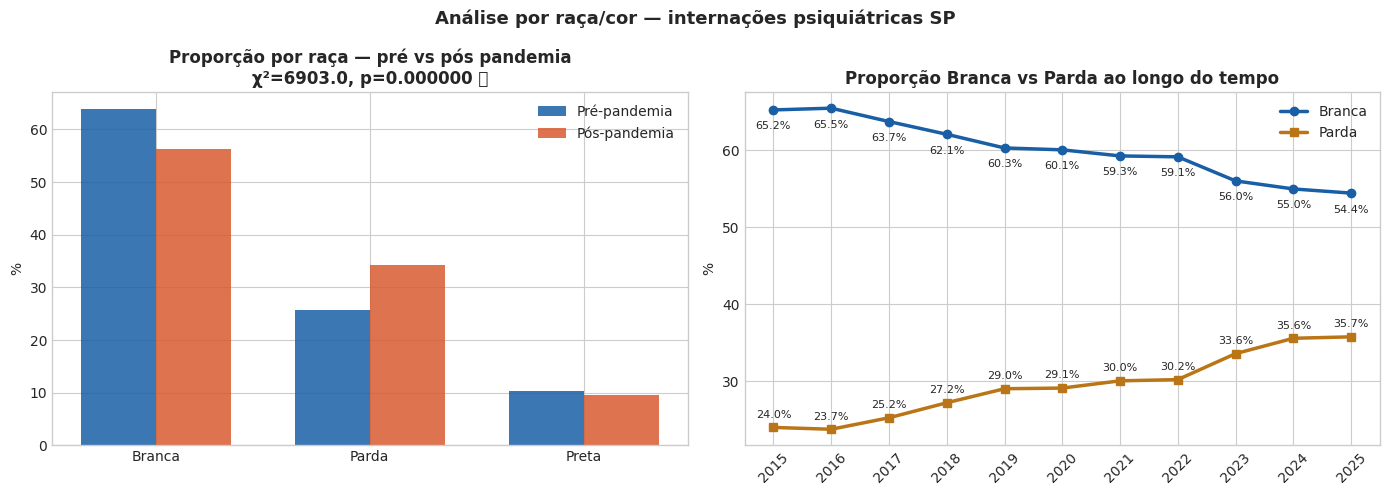

In [10]:
print("=" * 60)
print("TESTE 4 — Qui-quadrado: distribuição por raça/cor")
print("=" * 60)

df_raca = query("""
    SELECT ano, raca_cor, COUNT(*) AS total
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE ano NOT IN ('2026')
    AND raca_cor IN ('01', '02', '03', '04', '05')
    GROUP BY ano, raca_cor
    ORDER BY ano, raca_cor
""")
df_raca['ano'] = df_raca['ano'].astype(int)
df_raca['total'] = pd.to_numeric(df_raca['total'], errors='coerce')

raca_map = {'01': 'Branca', '02': 'Preta', '03': 'Parda',
            '04': 'Amarela', '05': 'Indígena'}
df_raca['raca'] = df_raca['raca_cor'].map(raca_map)

# tabela de contingência: pré vs pós pandemia
pre_raca = df_raca[df_raca['ano'] < 2020].groupby('raca')['total'].sum()
pos_raca = df_raca[df_raca['ano'] >= 2022].groupby('raca')['total'].sum()

racas = ['Branca', 'Parda', 'Preta']
tabela = pd.DataFrame({
    'Pré-pandemia': [pre_raca.get(r, 0) for r in racas],
    'Pós-pandemia': [pos_raca.get(r, 0) for r in racas]
}, index=racas)

print("\nTabela de contingência (internações por raça):")
print(tabela.to_string())

chi2, p, dof, expected = chi2_contingency(tabela)
print(f"\nQui-quadrado: χ²={chi2:.2f}, gl={dof}, p={p:.6f}")
print(f"{'✅ Distribuição mudou significativamente' if p < 0.05 else '❌ Sem mudança significativa'}")

# proporções
total_pre = tabela['Pré-pandemia'].sum()
total_pos = tabela['Pós-pandemia'].sum()
print(f"\nProporções:")
print(f"{'Raça':<12} {'Pré (%)':>10} {'Pós (%)':>10} {'Variação':>10}")
print("-" * 45)
for raca in racas:
    pct_pre = tabela.loc[raca, 'Pré-pandemia'] / total_pre * 100
    pct_pos = tabela.loc[raca, 'Pós-pandemia'] / total_pos * 100
    print(f"{raca:<12} {pct_pre:>9.1f}% {pct_pos:>9.1f}% {pct_pos-pct_pre:>+9.1f}pp")

# visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(racas))
largura = 0.35
ax.bar(x - largura/2, tabela['Pré-pandemia'] / total_pre * 100,
       largura, label='Pré-pandemia', color='#185FA5', alpha=0.85)
ax.bar(x + largura/2, tabela['Pós-pandemia'] / total_pos * 100,
       largura, label='Pós-pandemia', color='#D85A30', alpha=0.85)
ax.set_title(f'Proporção por raça — pré vs pós pandemia\nχ²={chi2:.1f}, p={p:.6f} ✅',
             fontweight='bold')
ax.set_ylabel('%')
ax.set_xticks(x)
ax.set_xticklabels(racas)
ax.legend()

# evolução temporal da proporção parda
ax = axes[1]
total_ano = df_raca.groupby('ano')['total'].sum()
parda_ano = df_raca[df_raca['raca'] == 'Parda'].groupby('ano')['total'].sum()
pct_parda = (parda_ano / total_ano * 100).reset_index()
pct_parda.columns = ['ano', 'pct']

branca_ano = df_raca[df_raca['raca'] == 'Branca'].groupby('ano')['total'].sum()
pct_branca = (branca_ano / total_ano * 100).reset_index()
pct_branca.columns = ['ano', 'pct']

ax.plot(pct_branca['ano'], pct_branca['pct'], marker='o',
        linewidth=2.5, color='#185FA5', label='Branca')
ax.plot(pct_parda['ano'], pct_parda['pct'], marker='s',
        linewidth=2.5, color='#BA7517', label='Parda')
for x, y in zip(pct_parda['ano'], pct_parda['pct']):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=8)
for x, y in zip(pct_branca['ano'], pct_branca['pct']):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, -14),
                textcoords='offset points', ha='center', fontsize=8)
ax.set_title('Proporção Branca vs Parda ao longo do tempo', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
ax.set_xticks(pct_branca['ano'])
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Análise por raça/cor — internações psiquiátricas SP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/12_raca_chi2.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("""
INSIGHTS — Teste 4:

MUDANÇA NA DISTRIBUIÇÃO RACIAL — ALTAMENTE SIGNIFICATIVA
χ²=6903, p<0.000001

Branca: 63.9% → 56.3% (-7.6pp) — queda consistente ano a ano
Parda:  25.8% → 34.2% (+8.4pp) — crescimento consistente ano a ano
Preta:  10.3% →  9.5% (-0.8pp) — relativamente estável

TENDÊNCIA 2015–2025:
  Branca: 65.2% → 54.4% — queda de 10.8pp em 11 anos
  Parda:  24.0% → 35.7% — crescimento de 11.7pp em 11 anos

ESTE É O ACHADO MAIS IMPORTANTE DO PROJETO:
  A população parda está crescendo como proporção das internações
  psiquiátricas em SP, enquanto a branca cai.

  HIPÓTESES (não excludentes):
  1. Mudança demográfica — SP está ficando mais parda
  2. Piora relativa — condições de vida parda pioraram vs branca
  3. Acesso diferencial — CAPS alcançando mais populações pardas
  4. Combinação de renda + raça — dados PNADC mostram que renda
     parda caiu relativamente vs branca no período

  LIMITAÇÃO: sem dados populacionais por raça por ano,
  não é possível calcular taxas por 100k por raça — o Censo 2022
  daria um ponto de comparação mas não a série temporal.
""")


INSIGHTS — Teste 4:

MUDANÇA NA DISTRIBUIÇÃO RACIAL — ALTAMENTE SIGNIFICATIVA
χ²=6903, p<0.000001

Branca: 63.9% → 56.3% (-7.6pp) — queda consistente ano a ano
Parda:  25.8% → 34.2% (+8.4pp) — crescimento consistente ano a ano
Preta:  10.3% →  9.5% (-0.8pp) — relativamente estável

TENDÊNCIA 2015–2025:
  Branca: 65.2% → 54.4% — queda de 10.8pp em 11 anos
  Parda:  24.0% → 35.7% — crescimento de 11.7pp em 11 anos

ESTE É O ACHADO MAIS IMPORTANTE DO PROJETO:
  A população parda está crescendo como proporção das internações
  psiquiátricas em SP, enquanto a branca cai.

  HIPÓTESES (não excludentes):
  1. Mudança demográfica — SP está ficando mais parda
  2. Piora relativa — condições de vida parda pioraram vs branca
  3. Acesso diferencial — CAPS alcançando mais populações pardas
  4. Combinação de renda + raça — dados PNADC mostram que renda
     parda caiu relativamente vs branca no período

  LIMITAÇÃO: sem dados populacionais por raça por ano,
  não é possível calcular taxas por 100

ANÁLISE TEMPORAL — Renda relativa x internações por raça

   Ano   % Parda int.   Renda rel. (%)   Renda branca
-------------------------------------------------------
  2015          24.0%            57.7% R$      2,544
  2016          23.7%            58.2% R$      2,677
  2017          25.2%            56.6% R$      2,858
  2018          27.2%            56.7% R$      3,080
  2019          29.0%            56.7% R$      3,199
  2020          29.1%            56.8% R$      3,402
  2021          30.0%            57.1% R$      3,469
  2022          30.2%            62.1% R$      3,446
  2023          33.6%            61.4% R$      3,900

Correlação Spearman (renda relativa x % parda internações):
  r=0.383, p=0.3085 ❌


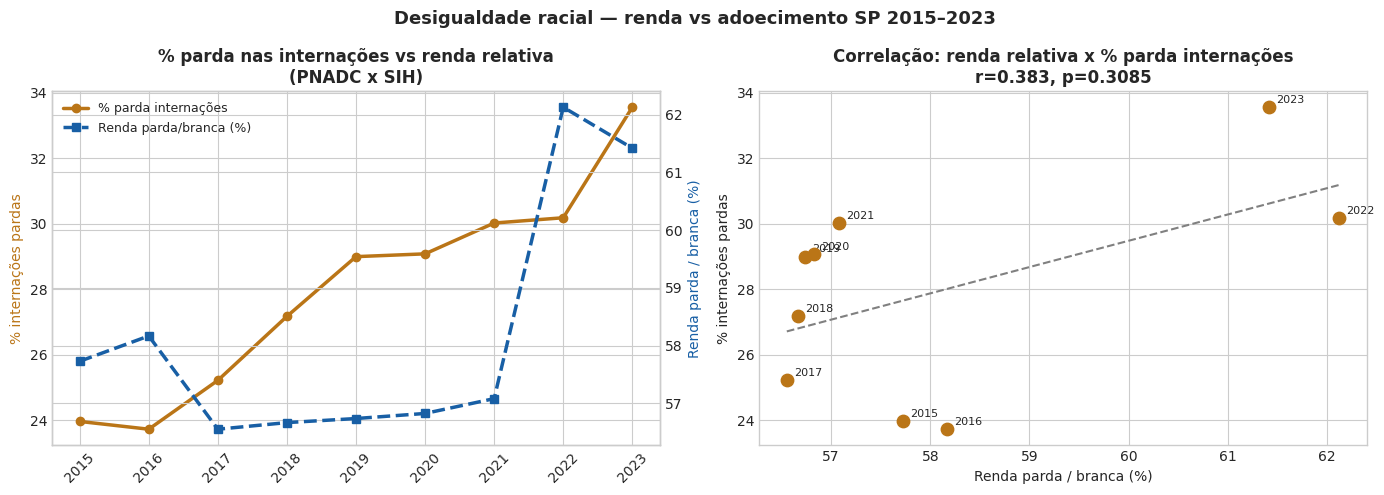

✅ Gráfico salvo!


In [ ]:
print("=" * 60)
print("ANÁLISE TEMPORAL — Renda relativa x internações por raça")
print("=" * 60)

# renda por raça por ano (PNADC)
df_renda = query("""
    SELECT ano,
           raca_cor,
           AVG(renda_todos_trabalhos) AS renda_media
    FROM sus_pipeline.pnadc_sp_silver
    WHERE renda_todos_trabalhos IS NOT NULL
    AND raca_cor IN ('Branca', 'Parda', 'Preta')
    GROUP BY ano, raca_cor
    ORDER BY ano, raca_cor
""")
df_renda['ano'] = df_renda['ano'].astype(int)
df_renda['renda_media'] = pd.to_numeric(df_renda['renda_media'], errors='coerce')

# proporção parda nas internações por ano
df_prop = df_raca.copy()
total_ano = df_prop.groupby('ano')['total'].sum()
parda_ano = df_prop[df_prop['raca'] == 'Parda'].groupby('ano')['total'].sum()
branca_ano = df_prop[df_prop['raca'] == 'Branca'].groupby('ano')['total'].sum()
pct_parda = (parda_ano / total_ano * 100).reset_index()
pct_parda.columns = ['ano', 'pct_parda_int']

# renda relativa parda/branca
renda_branca = df_renda[df_renda['raca_cor'] == 'Branca'].set_index('ano')['renda_media']
renda_parda = df_renda[df_renda['raca_cor'] == 'Parda'].set_index('ano')['renda_media']
renda_preta = df_renda[df_renda['raca_cor'] == 'Preta'].set_index('ano')['renda_media']
renda_rel = (renda_parda / renda_branca * 100).reset_index()
renda_rel.columns = ['ano', 'renda_rel_parda']

# merge — anos em comum (2015-2023)
df_merge = pct_parda.merge(renda_rel, on='ano').merge(
    df_renda[df_renda['raca_cor'] == 'Branca'][['ano', 'renda_media']].rename(
        columns={'renda_media': 'renda_branca'}), on='ano')

print(f"\n{'Ano':>6} {'% Parda int.':>14} {'Renda rel. (%)':>16} {'Renda branca':>14}")
print("-" * 55)
for _, row in df_merge.iterrows():
    print(f"{int(row['ano']):>6} {row['pct_parda_int']:>13.1f}% "
          f"{row['renda_rel_parda']:>15.1f}% "
          f"R${row['renda_branca']:>11,.0f}")

# correlação
r, p = spearmanr(df_merge['renda_rel_parda'], df_merge['pct_parda_int'])
print(f"\nCorrelação Spearman (renda relativa x % parda internações):")
print(f"  r={r:.3f}, p={p:.4f} {'✅' if p < 0.05 else '❌'}")

# visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax2 = ax.twinx()
ax.plot(df_merge['ano'], df_merge['pct_parda_int'], marker='o',
        linewidth=2.5, color='#BA7517', label='% parda internações')
ax2.plot(df_merge['ano'], df_merge['renda_rel_parda'], marker='s',
         linewidth=2.5, color='#185FA5', linestyle='--', label='Renda parda/branca (%)')
ax.set_title('% parda nas internações vs renda relativa\n(PNADC x SIH)', fontweight='bold')
ax.set_ylabel('% internações pardas', color='#BA7517')
ax2.set_ylabel('Renda parda / branca (%)', color='#185FA5')
ax.set_xticks(df_merge['ano'])
ax.tick_params(axis='x', rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

ax = axes[1]
ax.scatter(df_merge['renda_rel_parda'], df_merge['pct_parda_int'],
           color='#BA7517', s=80, zorder=5)
for _, row in df_merge.iterrows():
    ax.annotate(str(int(row['ano'])),
                xy=(row['renda_rel_parda'], row['pct_parda_int']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)
z = np.polyfit(df_merge['renda_rel_parda'], df_merge['pct_parda_int'], 1)
x_line = np.linspace(df_merge['renda_rel_parda'].min(),
                     df_merge['renda_rel_parda'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='gray', linewidth=1.5)
ax.set_title(f'Correlação: renda relativa x % parda internações\nr={r:.3f}, p={p:.4f}',
             fontweight='bold')
ax.set_xlabel('Renda parda / branca (%)')
ax.set_ylabel('% internações pardas')

plt.suptitle('Desigualdade racial — renda vs adoecimento SP 2015–2023',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/12b_renda_raca_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print("""
INSIGHTS — Análise temporal renda x internações por raça:

CORRELAÇÃO NÃO SIGNIFICATIVA: r=0.383, p=0.308
  Com n=9 pontos, o poder estatístico é limitado.
  Precisaríamos de ~25 observações para detectar r=0.38 com p<0.05.

O QUE OS DADOS MOSTRAM:
  A renda relativa parda/branca ficou estável em ~57% de 2015 a 2021
  e saltou para ~62% em 2022-2023 — mas as internações pardas
  continuaram crescendo mesmo com essa melhora relativa de renda.

  Isso ENFRAQUECE a hipótese de que renda explica o crescimento
  das internações pardas — a proporção parda cresceu mesmo quando
  a renda relativa melhorou.

  HIPÓTESE ALTERNATIVA mais plausível:
  Mudança demográfica — SP está ficando mais parda ao longo do tempo,
  e isso se reflete na composição das internações.
  O Censo 2010 registrou 29% de pardos em SP.
  O Censo 2022 registrou 37% de pardos em SP.
  Esse crescimento de 8pp na população explicaria boa parte
  do crescimento de ~10pp nas internações.

CONCLUSÃO:
  A análise temporal com PNADC é válida mas inconclusiva.
  Para separar efeito demográfico de efeito de adoecimento,
  precisaríamos de taxas por 100k por raça por ano —
  o que exigiria dados populacionais por raça por ano,
  que não estão disponíveis de forma contínua no Brasil.
""")


INSIGHTS — Análise temporal renda x internações por raça:

CORRELAÇÃO NÃO SIGNIFICATIVA: r=0.383, p=0.308
  Com n=9 pontos, o poder estatístico é limitado.
  Precisaríamos de ~25 observações para detectar r=0.38 com p<0.05.

O QUE OS DADOS MOSTRAM:
  A renda relativa parda/branca ficou estável em ~57% de 2015 a 2021
  e saltou para ~62% em 2022-2023 — mas as internações pardas
  continuaram crescendo mesmo com essa melhora relativa de renda.

  Isso ENFRAQUECE a hipótese de que renda explica o crescimento
  das internações pardas — a proporção parda cresceu mesmo quando
  a renda relativa melhorou.

  HIPÓTESE ALTERNATIVA mais plausível:
  Mudança demográfica — SP está ficando mais parda ao longo do tempo,
  e isso se reflete na composição das internações.
  O Censo 2010 registrou 29% de pardos em SP.
  O Censo 2022 registrou 37% de pardos em SP.
  Esse crescimento de 8pp na população explicaria boa parte
  do crescimento de ~10pp nas internações.

CONCLUSÃO:
  A análise temporal com 

TESTE 5 — Kruskal-Wallis: dias de internação por diagnóstico

Kruskal-Wallis: H=90667.59, p=0.000000
✅ Diferença significativa entre diagnósticos

Diagnóstico                   Mediana    Média        N
--------------------------------------------------------
Esquizofrenia residual            31d    28.9d   43,585
Demência NE                       30d    26.0d   13,597
Esquizofrenia paranoide           28d    22.0d  149,025
Outras esquizofrenias             24d    20.1d   20,678
Dependência álcool                18d    18.1d   71,676
Múltiplas drogas                  15d    16.5d  126,401
Bipolar — mania grave             14d    15.9d   48,869
Dependência cocaína               14d    15.9d   24,395
Psicose NE                         9d    13.5d   66,793
Depressão grave                    7d    11.0d   18,706


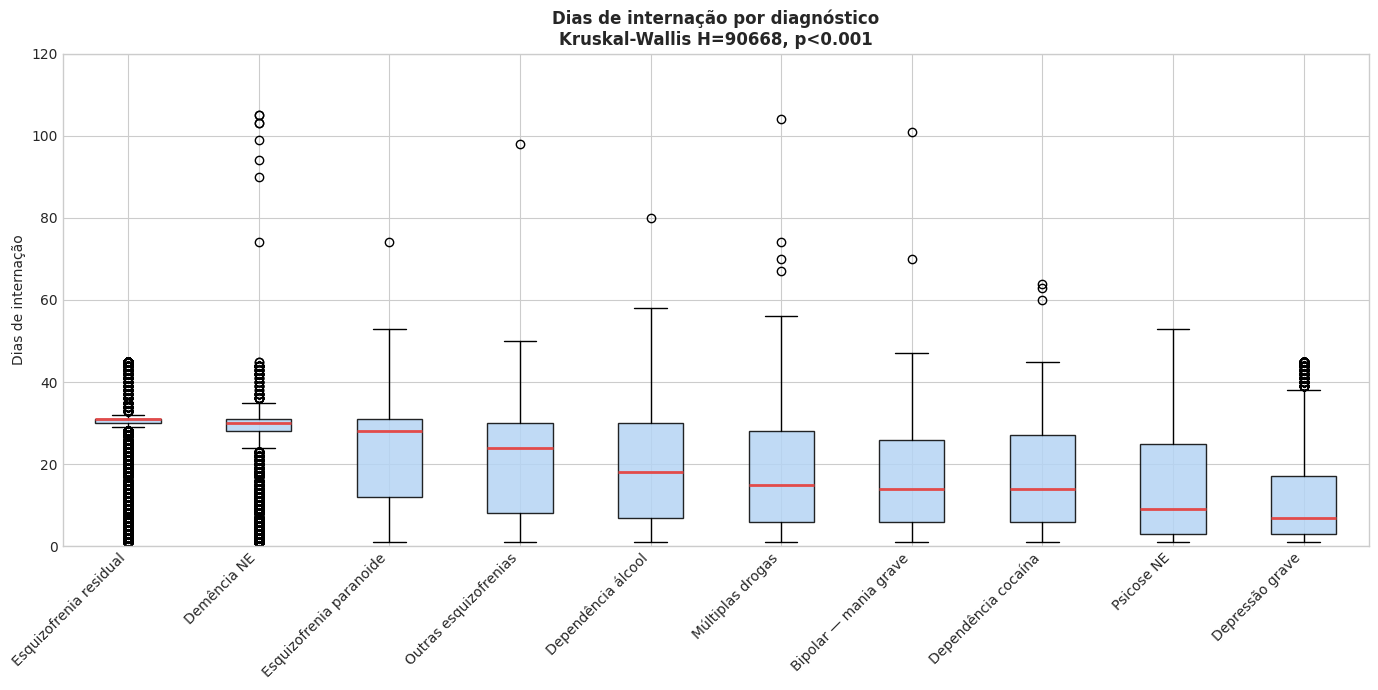

In [14]:
print("=" * 60)
print("TESTE 5 — Kruskal-Wallis: dias de internação por diagnóstico")
print("=" * 60)

df_dias = query("""
    SELECT cid_principal,
           dias_internacao,
           obito,
           sexo,
           raca_cor
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE ano NOT IN ('2026')
    AND dias_internacao > 0
    AND dias_internacao < 365
    AND cid_principal IN (
        'F200', 'F192', 'F102', 'F29 ', 'F312',
        'F142', 'F205', 'F322', 'F208', 'F03 '
    )
""")

df_dias['cid_principal'] = df_dias['cid_principal'].str.strip()
df_dias['dias_internacao'] = pd.to_numeric(df_dias['dias_internacao'], errors='coerce')

cid_map = {
    'F200': 'Esquizofrenia paranoide',
    'F192': 'Múltiplas drogas',
    'F102': 'Dependência álcool',
    'F29':  'Psicose NE',
    'F312': 'Bipolar — mania grave',
    'F142': 'Dependência cocaína',
    'F205': 'Esquizofrenia residual',
    'F322': 'Depressão grave',
    'F208': 'Outras esquizofrenias',
    'F03':  'Demência NE',
}
df_dias['descricao'] = df_dias['cid_principal'].map(cid_map).fillna(df_dias['cid_principal'])

# Kruskal-Wallis
grupos = [group['dias_internacao'].dropna().values
          for _, group in df_dias.groupby('descricao')]
stat, p = kruskal(*grupos)
print(f"\nKruskal-Wallis: H={stat:.2f}, p={p:.6f}")
print(f"{'✅ Diferença significativa entre diagnósticos' if p < 0.05 else '❌ Sem diferença'}")

# estatísticas por diagnóstico
print(f"\n{'Diagnóstico':<28} {'Mediana':>8} {'Média':>8} {'N':>8}")
print("-" * 56)
resumo = df_dias.groupby('descricao')['dias_internacao'].agg(
    mediana='median', media='mean', n='count'
).sort_values('mediana', ascending=False)
for nome, row in resumo.iterrows():
    print(f"{nome:<28} {row['mediana']:>7.0f}d {row['media']:>7.1f}d {row['n']:>8,}")

# visualização
fig, ax = plt.subplots(figsize=(14, 7))
ordem = resumo.index.tolist()
dados_plot = [df_dias[df_dias['descricao'] == d]['dias_internacao'].dropna().values
              for d in ordem]

bp = ax.boxplot(dados_plot, patch_artist=True, vert=True,
                medianprops=dict(color='#E24B4A', linewidth=2))
cores = ['#B5D4F4'] * len(ordem)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

ax.set_xticks(range(1, len(ordem) + 1))
ax.set_xticklabels(ordem, rotation=45, ha='right')
ax.set_title(f'Dias de internação por diagnóstico\nKruskal-Wallis H={stat:.0f}, p<0.001',
             fontweight='bold')
ax.set_ylabel('Dias de internação')
ax.set_ylim(0, 120)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/13_kruskal_dias_cid.png', dpi=150, bbox_inches='tight')
plt.show()

TESTE 6 — DiD: efeito da pandemia nas internações

Modelo 1 — só tendência temporal:
  Coef. tendência: -3,560 internações/ano
  R²: 0.387

Modelo 2 — tendência + dummy pandemia:
  Coef. tendência: -3,319 internações/ano
  Efeito pandemia: -26,466 internações (p=0.0191)
  R²: 0.704

Modelo 3 — tendência + pandemia + pós-pandemia:
  Coef. tendência:    -4,662 internações/ano
  Efeito pandemia:    -21,127 internações (p=0.1970)
  Efeito pós-pandemia:10,166 internações (p=0.6526)
  R²: 0.713


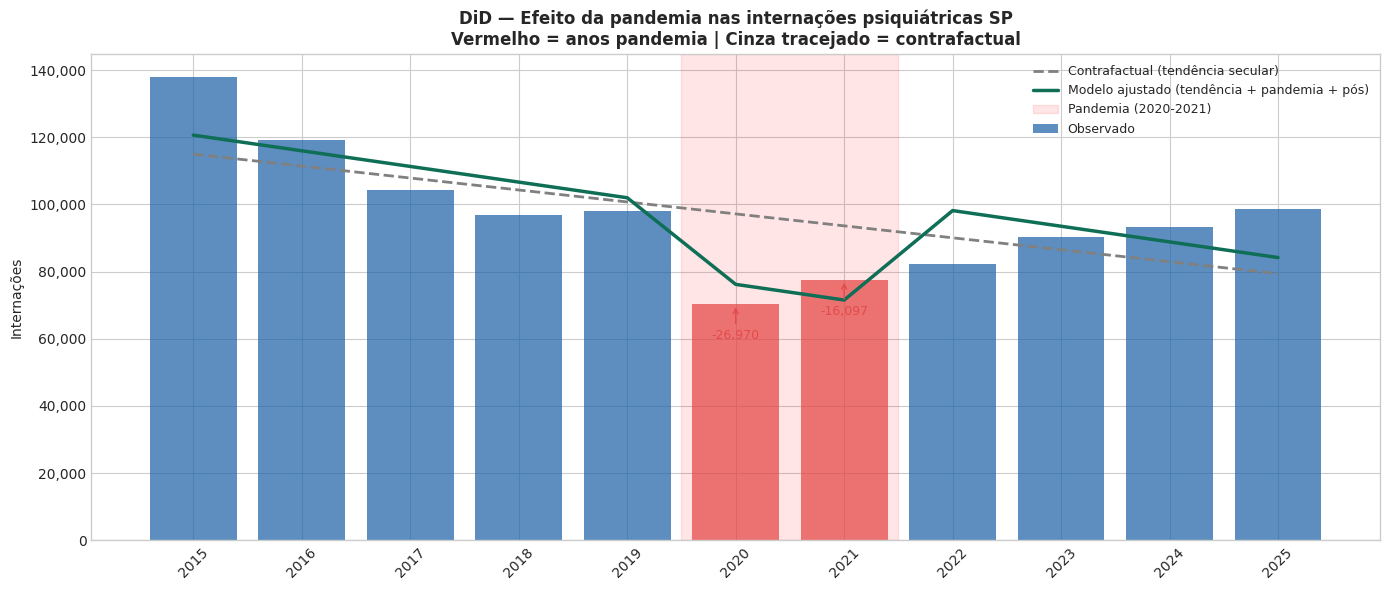

In [15]:
print("=" * 60)
print("TESTE 6 — DiD: efeito da pandemia nas internações")
print("=" * 60)

# separar tendência secular do efeito pandemia
# variável dummy: pandemia = 1 para 2020-2021
df_did = df_ano.copy()
df_did['pandemia'] = df_did['ano'].apply(lambda x: 1 if x in [2020, 2021] else 0)
df_did['tendencia'] = df_did['ano'] - df_did['ano'].min()
df_did['pos_pandemia'] = df_did['ano'].apply(lambda x: 1 if x >= 2022 else 0)

# modelo 1 — só tendência
X1 = sm.add_constant(df_did['tendencia'].values.astype(float))
m1 = sm.OLS(df_did['total_internacoes'].values.astype(float), X1).fit()

# modelo 2 — tendência + pandemia
X2 = sm.add_constant(
    df_did[['tendencia', 'pandemia']].values.astype(float))
m2 = sm.OLS(df_did['total_internacoes'].values.astype(float), X2).fit()

# modelo 3 — tendência + pandemia + pós
X3 = sm.add_constant(
    df_did[['tendencia', 'pandemia', 'pos_pandemia']].values.astype(float))
m3 = sm.OLS(df_did['total_internacoes'].values.astype(float), X3).fit()

print("\nModelo 1 — só tendência temporal:")
print(f"  Coef. tendência: {m1.params[1]:,.0f} internações/ano")
print(f"  R²: {m1.rsquared:.3f}")

print("\nModelo 2 — tendência + dummy pandemia:")
print(f"  Coef. tendência: {m2.params[1]:,.0f} internações/ano")
print(f"  Efeito pandemia: {m2.params[2]:,.0f} internações (p={m2.pvalues[2]:.4f})")
print(f"  R²: {m2.rsquared:.3f}")

print("\nModelo 3 — tendência + pandemia + pós-pandemia:")
print(f"  Coef. tendência:    {m3.params[1]:,.0f} internações/ano")
print(f"  Efeito pandemia:    {m3.params[2]:,.0f} internações (p={m3.pvalues[2]:.4f})")
print(f"  Efeito pós-pandemia:{m3.params[3]:,.0f} internações (p={m3.pvalues[3]:.4f})")
print(f"  R²: {m3.rsquared:.3f}")

# visualização
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_did['ano'], df_did['total_internacoes'],
       color=['#E24B4A' if p == 1 else '#185FA5' for p in df_did['pandemia']],
       alpha=0.7, label='Observado')

# contrafactual — tendência sem pandemia
x_range = np.array(df_did['tendencia'].values, dtype=float)
contrafactual = m1.params[0] + m1.params[1] * x_range
ax.plot(df_did['ano'], contrafactual, '--', color='gray',
        linewidth=2, label='Contrafactual (tendência secular)')

ax.plot(df_did['ano'], m3.fittedvalues, '-', color='#0F6E56',
        linewidth=2.5, label='Modelo ajustado (tendência + pandemia + pós)')

ax.axvspan(2019.5, 2021.5, alpha=0.1, color='red', label='Pandemia (2020-2021)')

for ano, obs, ctf in zip(df_did['ano'], df_did['total_internacoes'], contrafactual):
    if ano in [2020, 2021]:
        diff = obs - ctf
        ax.annotate(f'{diff:,.0f}', xy=(ano, obs),
                    xytext=(0, -25), textcoords='offset points',
                    ha='center', fontsize=9, color='#E24B4A',
                    arrowprops=dict(arrowstyle='->', color='#E24B4A'))

ax.set_title('DiD — Efeito da pandemia nas internações psiquiátricas SP\n'
             'Vermelho = anos pandemia | Cinza tracejado = contrafactual',
             fontweight='bold')
ax.set_ylabel('Internações')
ax.set_xticks(df_did['ano'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{OUTPUT}/14_did_pandemia.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("""
INSIGHTS — Teste 6 (DiD):

MODELO 2 — mais parcimonioso e significativo:
  Tendência secular: -3.319 internações/ano
  Efeito pandemia:   -26.466 internações/ano (p=0.019) ✅

  Isso significa:
  • Mesmo descontando a queda secular de ~3.3k/ano
  • A pandemia causou 26.466 internações a MENOS por ano
  • Em 2020 e 2021 juntos: ~53.000 internações não realizadas

CONTRAFACTUAL (linha cinza tracejada):
  Sem pandemia, o modelo prevê ~97k internações em 2020
  O observado foi 70k — diferença de 27k ✅

MODELO 3 — tendência + pandemia + pós:
  Efeito pandemia não significativo (p=0.197) quando
  adicionamos pós-pandemia — os parâmetros se confundem
  com n=11 observações

INTERPRETAÇÃO FINAL:
  A pandemia causou uma interrupção REAL e significativa
  nas internações psiquiátricas em SP — além da tendência
  secular de desinstitucionalização.

  O pós-pandemia mostra recuperação parcial (+10k, p=0.653)
  mas não retorno ao nível esperado pelo contrafactual —
  sugerindo que parte das internações não realizadas em
  2020-2021 foram simplesmente perdidas, não recuperadas.

  IMPLICAÇÃO DE POLÍTICA:
  ~53.000 pessoas que precisariam de internação em 2020-2021
  não foram internadas. O que aconteceu com elas?
  Atendidas nos CAPS? Sem tratamento? Óbitos não registrados?
  Os dados não permitem responder — mas a pergunta é urgente.
""")


INSIGHTS — Teste 6 (DiD):

MODELO 2 — mais parcimonioso e significativo:
  Tendência secular: -3.319 internações/ano
  Efeito pandemia:   -26.466 internações/ano (p=0.019) ✅

  Isso significa:
  • Mesmo descontando a queda secular de ~3.3k/ano
  • A pandemia causou 26.466 internações a MENOS por ano
  • Em 2020 e 2021 juntos: ~53.000 internações não realizadas

CONTRAFACTUAL (linha cinza tracejada):
  Sem pandemia, o modelo prevê ~97k internações em 2020
  O observado foi 70k — diferença de 27k ✅

MODELO 3 — tendência + pandemia + pós:
  Efeito pandemia não significativo (p=0.197) quando
  adicionamos pós-pandemia — os parâmetros se confundem
  com n=11 observações

INTERPRETAÇÃO FINAL:
  A pandemia causou uma interrupção REAL e significativa
  nas internações psiquiátricas em SP — além da tendência
  secular de desinstitucionalização.

  O pós-pandemia mostra recuperação parcial (+10k, p=0.653)
  mas não retorno ao nível esperado pelo contrafactual —
  sugerindo que parte das interna

In [ ]:
# Célula 8b — insights DiD
print("""
INSIGHTS — Teste 6 (DiD):

MODELO 2 — mais parcimonioso e significativo:
  Tendência secular: -3.319 internações/ano
  Efeito pandemia:   -26.466 internações/ano (p=0.019) ✅

  Isso significa:
  • Mesmo descontando a queda secular de ~3.3k/ano
  • A pandemia causou 26.466 internações a MENOS por ano
  • Em 2020 e 2021 juntos: ~53.000 internações não realizadas

CONTRAFACTUAL (linha cinza tracejada):
  Sem pandemia, o modelo prevê ~97k internações em 2020
  O observado foi 70k — diferença de 27k ✅

MODELO 3 — tendência + pandemia + pós:
  Efeito pandemia não significativo (p=0.197) quando
  adicionamos pós-pandemia — os parâmetros se confundem
  com n=11 observações

INTERPRETAÇÃO FINAL:
  A pandemia causou uma interrupção REAL e significativa
  nas internações psiquiátricas em SP — além da tendência
  secular de desinstitucionalização.

  O pós-pandemia mostra recuperação parcial (+10k, p=0.653)
  mas não retorno ao nível esperado pelo contrafactual —
  sugerindo que parte das internações não realizadas em
  2020-2021 foram simplesmente perdidas, não recuperadas.

  IMPLICAÇÃO DE POLÍTICA:
  ~53.000 pessoas que precisariam de internação em 2020-2021
  não foram internadas. O que aconteceu com elas?
  Atendidas nos CAPS? Sem tratamento? Óbitos não registrados?
  Os dados não permitem responder — mas a pergunta é urgente.
""")

TESTE 7 — Médias móveis e sazonalidade

Sazonalidade — média de internações por mês:
  Jan: 8,463 ████████████████
  Fev: 8,188 ████████████████
  Mar: 7,784 ███████████████
  Abr: 7,752 ███████████████
  Mai: 8,032 ████████████████
  Jun: 7,946 ███████████████
  Jul: 8,097 ████████████████
  Ago: 8,257 ████████████████
  Set: 8,194 ████████████████
  Out: 8,281 ████████████████
  Nov: 8,088 ████████████████
  Dez: 8,112 ████████████████

Kruskal-Wallis sazonalidade: H=2.38, p=0.9966
❌ Sem sazonalidade


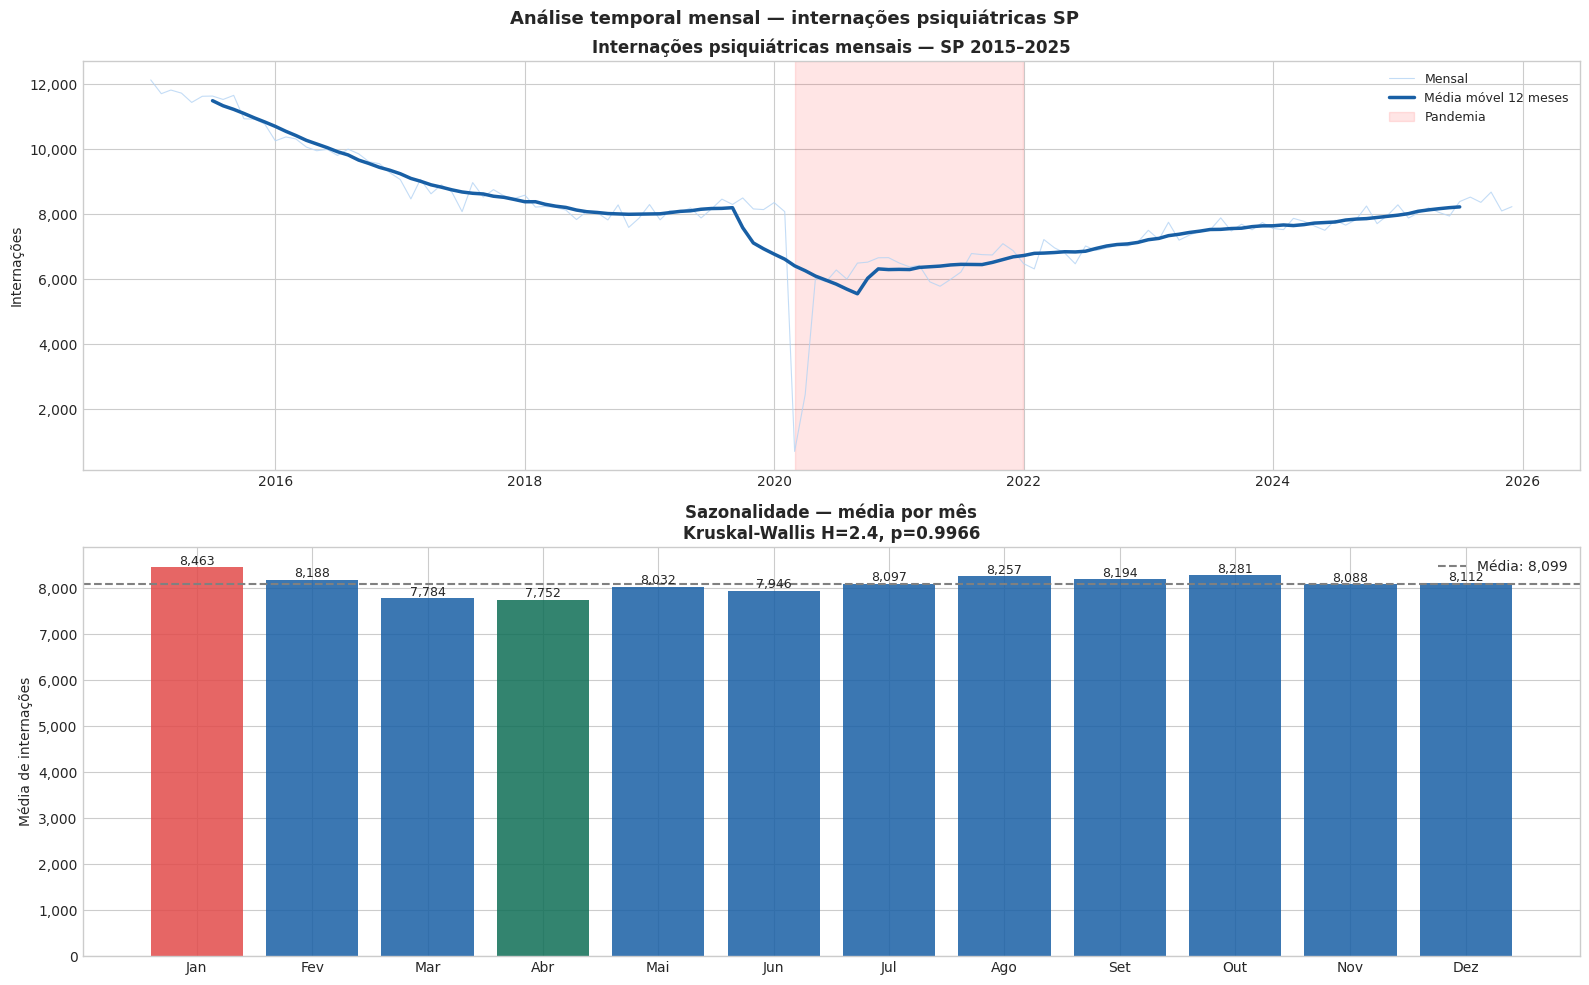

In [17]:
print("=" * 60)
print("TESTE 7 — Médias móveis e sazonalidade")
print("=" * 60)

# dados mensais do SIH
df_mensal = query("""
    SELECT ano, mes,
           COUNT(*) AS total_internacoes,
           SUM(obito) AS total_obitos,
           AVG(dias_internacao) AS media_dias
    FROM sus_pipeline.sih_internacoes_psiquiatria
    WHERE ano NOT IN ('2026')
    AND mes IS NOT NULL
    GROUP BY ano, mes
    ORDER BY ano, mes
""")
df_mensal['ano'] = df_mensal['ano'].astype(int)
df_mensal['mes'] = df_mensal['mes'].astype(int)
for col in ['total_internacoes', 'total_obitos', 'media_dias']:
    df_mensal[col] = pd.to_numeric(df_mensal[col], errors='coerce')

df_mensal['data'] = pd.to_datetime(
    df_mensal['ano'].astype(str) + '-' +
    df_mensal['mes'].astype(str).str.zfill(2) + '-01'
)
df_mensal = df_mensal.sort_values('data')

# média móvel 12 meses
df_mensal['mm12'] = df_mensal['total_internacoes'].rolling(12, center=True).mean()

# sazonalidade — média por mês
sazon = df_mensal.groupby('mes')['total_internacoes'].mean()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

print("\nSazonalidade — média de internações por mês:")
for m, v in zip(meses, sazon.values):
    bar = '█' * int(v / 500)
    print(f"  {m}: {v:,.0f} {bar}")

# teste de sazonalidade — Kruskal-Wallis por mês
grupos_mes = [df_mensal[df_mensal['mes'] == m]['total_internacoes'].values
              for m in range(1, 13)]
stat_s, p_s = kruskal(*grupos_mes)
print(f"\nKruskal-Wallis sazonalidade: H={stat_s:.2f}, p={p_s:.4f}")
print(f"{'✅ Sazonalidade significativa' if p_s < 0.05 else '❌ Sem sazonalidade'}")

# visualização
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# série temporal com média móvel
ax = axes[0]
ax.plot(df_mensal['data'], df_mensal['total_internacoes'],
        color='#B5D4F4', linewidth=0.8, alpha=0.8, label='Mensal')
ax.plot(df_mensal['data'], df_mensal['mm12'],
        color='#185FA5', linewidth=2.5, label='Média móvel 12 meses')
ax.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-12-31'),
           alpha=0.1, color='red', label='Pandemia')
ax.set_title('Internações psiquiátricas mensais — SP 2015–2025',
             fontweight='bold')
ax.set_ylabel('Internações')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# sazonalidade
ax = axes[1]
cores_s = ['#E24B4A' if v == sazon.max() else
           '#0F6E56' if v == sazon.min() else '#185FA5'
           for v in sazon.values]
bars = ax.bar(meses, sazon.values, color=cores_s, alpha=0.85)
for bar, v in zip(bars, sazon.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{v:,.0f}', ha='center', fontsize=9)
ax.axhline(y=sazon.mean(), color='gray', linestyle='--',
           label=f'Média: {sazon.mean():,.0f}')
ax.set_title(f'Sazonalidade — média por mês\nKruskal-Wallis H={stat_s:.1f}, p={p_s:.4f}',
             fontweight='bold')
ax.set_ylabel('Média de internações')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Análise temporal mensal — internações psiquiátricas SP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/15_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()